# Assignment 4

Before working on this assignment please read these instructions fully. In the submission area, you will notice that you can click the link to **Preview the Grading** for each step of the assignment. This is the criteria that will be used for peer grading. Please familiarize yourself with the criteria before beginning the assignment.

This assignment requires that you to find **at least** two datasets on the web which are related, and that you visualize these datasets to answer a question with the broad topic of **religious events or traditions** (see below) for the region of **Moscow, Moscow, Russia**, or **Russia** more broadly.

You can merge these datasets with data from different regions if you like! For instance, you might want to compare **Moscow, Moscow, Russia** to Ann Arbor, USA. In that case at least one source file must be about **Moscow, Moscow, Russia**.

You are welcome to choose datasets at your discretion, but keep in mind **they will be shared with your peers**, so choose appropriate datasets. Sensitive, confidential, illicit, and proprietary materials are not good choices for datasets for this assignment. You are welcome to upload datasets of your own as well, and link to them using a third party repository such as github, bitbucket, pastebin, etc. Please be aware of the Coursera terms of service with respect to intellectual property.

Also, you are welcome to preserve data in its original language, but for the purposes of grading you should provide english translations. You are welcome to provide multiple visuals in different languages if you would like!

As this assignment is for the whole course, you must incorporate principles discussed in the first week, such as having as high data-ink ratio (Tufte) and aligning with Cairo’s principles of truth, beauty, function, and insight.

Here are the assignment instructions:

 * State the region and the domain category that your data sets are about (e.g., **Moscow, Moscow, Russia** and **religious events or traditions**).
 * You must state a question about the domain category and region that you identified as being interesting.
 * You must provide at least two links to available datasets. These could be links to files such as CSV or Excel files, or links to websites which might have data in tabular form, such as Wikipedia pages.
 * You must upload an image which addresses the research question you stated. In addition to addressing the question, this visual should follow Cairo's principles of truthfulness, functionality, beauty, and insightfulness.
 * You must contribute a short (1-2 paragraph) written justification of how your visualization addresses your stated research question.

What do we mean by **religious events or traditions**?  For this category you might consider calendar events, demographic data about religion in the region and neighboring regions, participation in religious events, or how religious events relate to political events, social movements, or historical events.

## Tips
* Wikipedia is an excellent source of data, and I strongly encourage you to explore it for new data sources.
* Many governments run open data initiatives at the city, region, and country levels, and these are wonderful resources for localized data sources.
* Several international agencies, such as the [United Nations](http://data.un.org/), the [World Bank](http://data.worldbank.org/), the [Global Open Data Index](http://index.okfn.org/place/) are other great places to look for data.
* This assignment requires you to convert and clean datafiles. Check out the discussion forums for tips on how to do this from various sources, and share your successes with your fellow students!

## Example
Looking for an example? Here's what our course assistant put together for the **Ann Arbor, MI, USA** area using **sports and athletics** as the topic. [Example Solution File](./readonly/Assignment4_example.pdf)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib notebook

pd.options.display.max_rows = 8

### The first data source is a CSV file with the total number of space launches - successful and unsuccessful

In [2]:
# load a file with statistics of space launches from 1957-2018
statuses = ['Year', 'Success', 'Failed', 'Total']
launch_status = pd.read_csv('launch_status.csv', sep='\t', skiprows=1, names=statuses)
launch_status

,Year,Success,Failed,Total
0,1957,2,1,3
1,1958,8,20,28
2,1959,13,10,23
3,1960,21,19,40
...,...,...,...,...
58,2015,82,5,87
59,2016,83,2,85
60,2017,84,7,91
61,2018,112,2,114


### Let's build a plot graph to estimate the number of launches

<IPython.core.display.Javascript object>


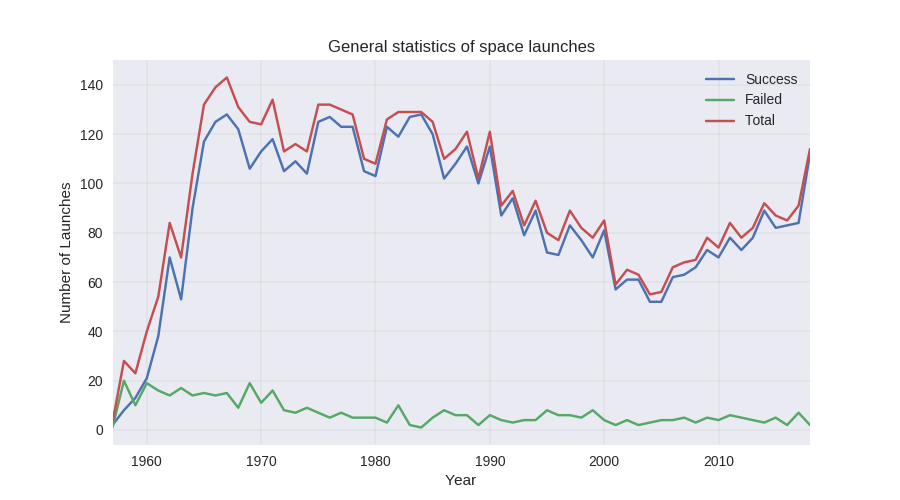

In [3]:
# Figure 1: the number of successful, unsuccessful and total launches by year
fig_1 = launch_status.set_index('Year').plot(figsize=[9, 5])
fig_1.set_title('General statistics of space launches')
fig_1.set_ylabel('Number of Launches')
fig_1.grid(color = 'gray', linewidth = 0.1, linestyle = '-');

### Add a column with the percentage of failed launches

In [4]:
launch_status['% Failed'] = launch_status['Failed'] * 100 / launch_status['Total']
launch_status

,Year,Success,Failed,Total,% Failed
0,1957,2,1,3,33.333333
1,1958,8,20,28,71.428571
2,1959,13,10,23,43.478261
3,1960,21,19,40,47.500000
...,...,...,...,...,...
58,2015,82,5,87,5.747126
59,2016,83,2,85,2.352941
60,2017,84,7,91,7.692308
61,2018,112,2,114,1.754386


### Wondering what the total number of launches looks like, taking into account the percentage of failed launches?

<IPython.core.display.Javascript object>


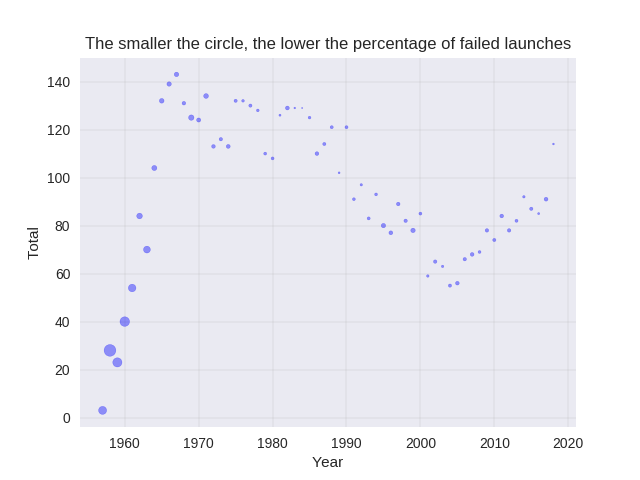

In [5]:
# Figure 2: the total number of launches by year with the relative number of failed launches
fig_2 = launch_status.plot.scatter('Year', 'Total', c='b', alpha=0.4, s=launch_status['% Failed'])
fig_2.set_title('The smaller the circle, the lower the percentage of failed launches')
fig_2.grid(color = 'gray', linewidth = 0.1, linestyle = '-');

### The good news is that the launch failure rate is clearly decreasing over the years. But how much?

<IPython.core.display.Javascript object>


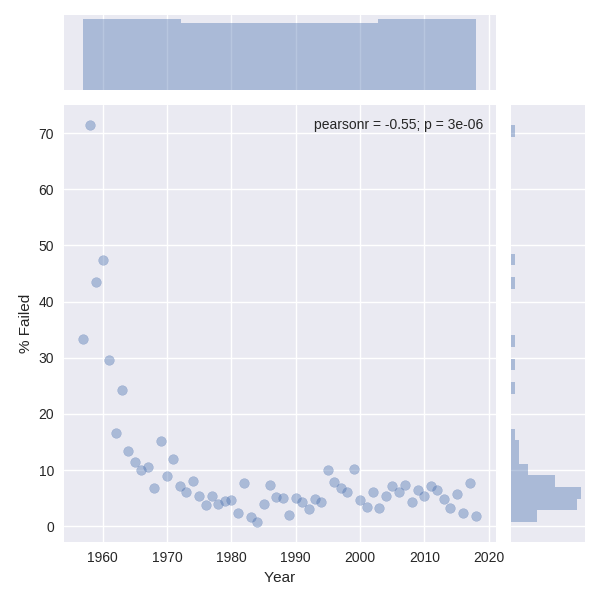

In [6]:
# Figure 3: percentage of failed launches by year with histograms
sns.jointplot(launch_status['Year'], launch_status['% Failed'], kind='scatter', alpha=0.4);

### Does the general trend seem to be tending to zero, or does it just seem so?

<IPython.core.display.Javascript object>


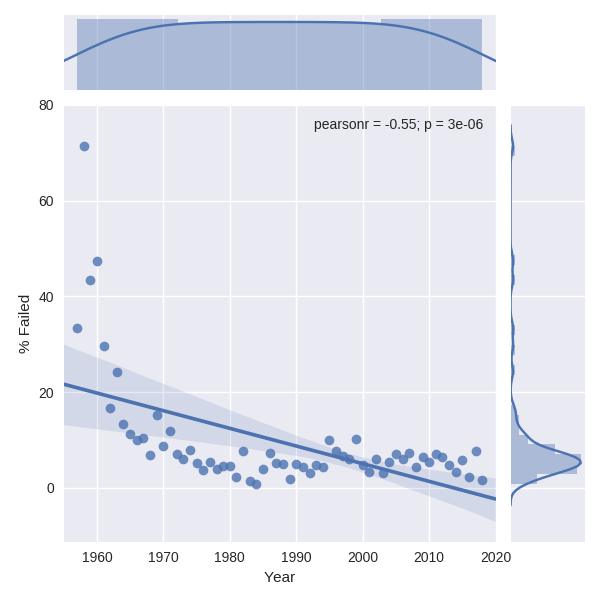

In [7]:
# Figure 4: let's add a linear regression fit and univariate KDE curves
fig_4 = sns.jointplot(launch_status['Year'], launch_status['% Failed'], kind='reg', xlim=[1955, 2020]);

### Yes, in the entire history of space launches, there is a clear trend towards a decrease in failed launches.
### But what is interesting, if we consider not the general situation, but for specific countries?
### The second data source is a CSV file with the number of space launches by countries.


In [8]:
country_names=['Russia', 'USA', 'France/EU', 'Japan', 'Italy', 'Australia', 'China', 'India', 'Israel', 'Brazil', 
               'North Korea', 'international', 'Iran', 'South Korea', 'New Zealand']
launch_country = pd.read_csv('launch_country.csv', sep='\t', skiprows=1, names=country_names)
launch_country

,Russia,USA,France/EU,Japan,Italy,Australia,China,India,Israel,Brazil,North Korea,international,Iran,South Korea,New Zealand
1957,2,1,0,0,0,0,0,0,0,0,0,0,0,0,0
1958,5,23,0,0,0,0,0,0,0,0,0,0,0,0,0
1959,4,19,0,0,0,0,0,0,0,0,0,0,0,0,0
1960,9,31,0,0,0,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2015,29,20,9,4,0,0,19,5,0,0,0,0,1,0,0
2016,19,22,9,4,0,0,22,7,1,0,1,0,0,0,0
2017,21,29,9,7,0,0,18,5,0,0,0,0,1,0,1
2018,20,31,8,6,0,0,39,7,0,0,0,0,0,0,3


### Let's look at the general timeline for the number of launches

<IPython.core.display.Javascript object>


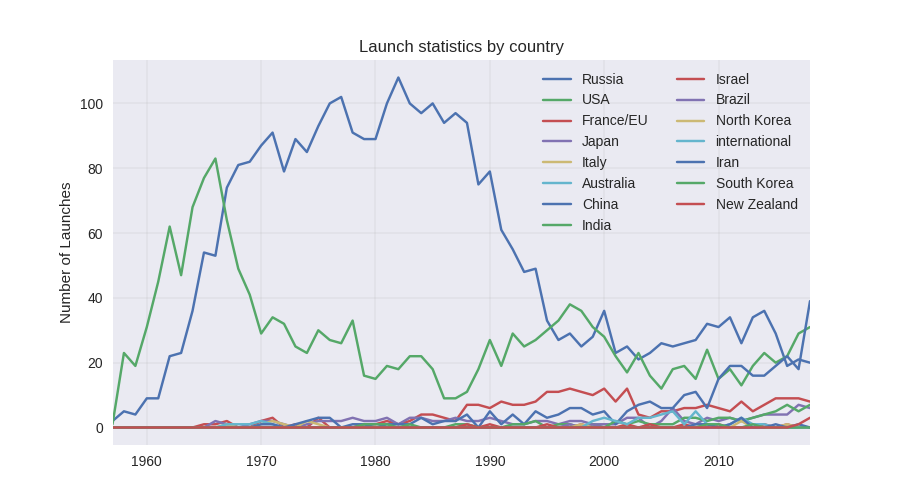

In [9]:
# Figure 5: number of launches in different countries by year
fig_5 = launch_country.plot(figsize=[9, 5])
fig_5.set_title('Launch statistics by country')
fig_5.set_ylabel('Number of Launches')
fig_5.grid(color = 'gray', linewidth = 0.1, linestyle = '-')
fig_5.legend(ncol = 2);

### Add a column for the total number of launches for all countries

In [10]:
launch_country['All countries'] = launch_country.sum(axis = 1)
launch_country

,Russia,USA,France/EU,Japan,Italy,Australia,China,India,Israel,Brazil,North Korea,international,Iran,South Korea,New Zealand,All countries
1957,2,1,0,0,0,0,0,0,0,0,0,0,0,0,0,3
1958,5,23,0,0,0,0,0,0,0,0,0,0,0,0,0,28
1959,4,19,0,0,0,0,0,0,0,0,0,0,0,0,0,23
1960,9,31,0,0,0,0,0,0,0,0,0,0,0,0,0,40
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2015,29,20,9,4,0,0,19,5,0,0,0,0,1,0,0,87
2016,19,22,9,4,0,0,22,7,1,0,1,0,0,0,0,85
2017,21,29,9,7,0,0,18,5,0,0,0,0,1,0,1,91
2018,20,31,8,6,0,0,39,7,0,0,0,0,0,0,3,114


### And let's check that for each year this amount matches with the total number of launches from the first source

In [11]:
((launch_country['All countries'] == launch_status.set_index('Year')['Total']) == True).all()

True

### It is clear that the vast majority of launches in history have been carried out by USA and Russia. Let's take a look at them...

In [12]:
launch_country = launch_country[['USA', 'Russia', 'All countries']]
launch_country

,USA,Russia,All countries
1957,1,2,3
1958,23,5,28
1959,19,4,23
1960,31,9,40
...,...,...,...
2015,20,29,87
2016,22,19,85
2017,29,21,91
2018,31,20,114


### It is interesting to look at the statistical distribution of launches

<IPython.core.display.Javascript object>


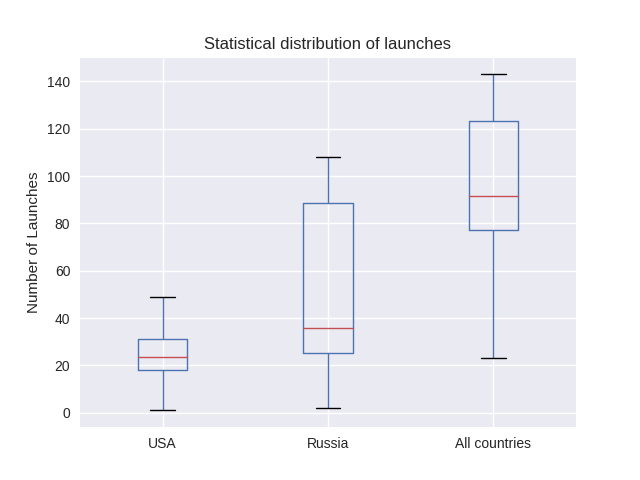

,USA,Russia,All countries
count,62.000000,62.000000,62.000000
mean,27.822581,52.612903,94.241935
std,15.904968,32.835584,31.207757
min,1.000000,2.000000,3.000000
25%,18.000000,25.250000,77.250000
50%,23.500000,36.000000,91.500000
75%,31.000000,88.500000,123.250000
max,83.000000,108.000000,143.000000


In [13]:
# Figure 6: boxplot and statistics by country
fig_6 = launch_country.plot.box()
fig_6.set_title('Statistical distribution of launches')
fig_6.set_ylabel('Number of Launches');
launch_country.describe()

### Although the averages for the United States and Russia differ by half, the median is only 1.5 times
### Let's see the same data taking into account the distribution density of launches.

<IPython.core.display.Javascript object>


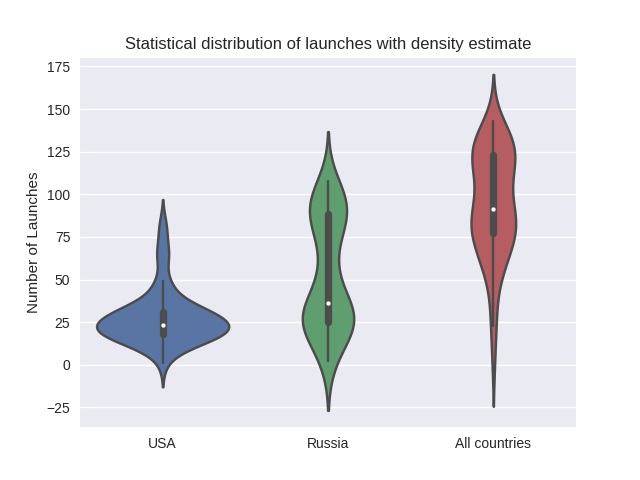

In [14]:
# Figure 7: a combination of boxplot and kernel density estimate.
plt.figure()
fig_7 = sns.violinplot(data = launch_country)
fig_7.set_title('Statistical distribution of launches with density estimate')
fig_7.set_ylabel('Number of Launches');

### However, we still do not know anything about the statistics of failed launches by country. 
### Let's merge our two tables and see if we can get something out of this.

In [15]:
launch_country_status = pd.merge(launch_country, launch_status, left_index = True, right_on = 'Year').set_index('Year')
launch_country_status

,USA,Russia,All countries,Success,Failed,Total,% Failed
Year,,,,,,,
1957,1,2,3,2,1,3,33.333333
1958,23,5,28,8,20,28,71.428571
1959,19,4,23,13,10,23,43.478261
1960,31,9,40,21,19,40,47.500000
...,...,...,...,...,...,...,...
2015,20,29,87,82,5,87,5.747126
2016,22,19,85,83,2,85,2.352941
2017,29,21,91,84,7,91,7.692308
2018,31,20,114,112,2,114,1.754386


### The first lines of this table show that initially a very high percentage of failed launches was distributed very unevenly across countries. For example, 20 failed launches in 1958 were clearly predominantly American, because Russia had only 5 launches that year. Conversely, the 23 failed launches in 1959 were almost all Russian.

### However, very soon the percentage of failed launches quickly began to decline and no longer rose above 20%. In this regard, it can be assumed that, as a first approximation, the number of failed launches in each country is proportional to the total number of launches in it.

### Let's look at the distribution of failed launches by country, based on this "zero approximation".

In [16]:
launch_country_status['% USA Failed'] = launch_country_status['% Failed'] * \
    (launch_country_status['USA'] / (launch_country_status['USA'] + launch_country_status['Russia']))
launch_country_status['% Russia Failed'] = launch_country_status['% Failed'] * \
    (launch_country_status['Russia'] / (launch_country_status['USA'] + launch_country_status['Russia']))
launch_country_status

,USA,Russia,All countries,Success,Failed,Total,% Failed,% USA Failed,% Russia Failed
Year,,,,,,,,,
1957,1,2,3,2,1,3,33.333333,11.111111,22.222222
1958,23,5,28,8,20,28,71.428571,58.673469,12.755102
1959,19,4,23,13,10,23,43.478261,35.916824,7.561437
1960,31,9,40,21,19,40,47.500000,36.812500,10.687500
...,...,...,...,...,...,...,...,...,...
2015,20,29,87,82,5,87,5.747126,2.345766,3.401361
2016,22,19,85,83,2,85,2.352941,1.262554,1.090387
2017,29,21,91,84,7,91,7.692308,4.461538,3.230769
2018,31,20,114,112,2,114,1.754386,1.066391,0.687994


### And let's see the difference in the density of distributions for the two countries, discarding atypical single "outliers"

<IPython.core.display.Javascript object>


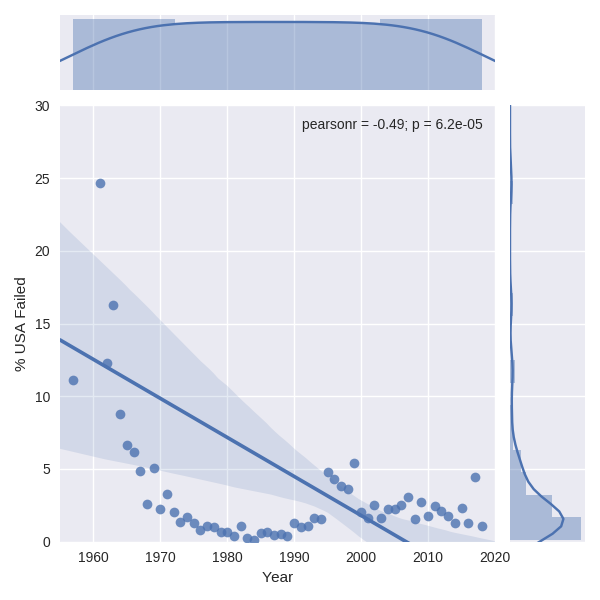

In [17]:
# Figure 8: USA jointplot with the y axis restricted to 30% value
fig_8 = sns.jointplot(launch_country_status.index, launch_country_status['% USA Failed'], kind='reg', 
                      xlim=[1955, 2020], ylim=[0, 30]);

<IPython.core.display.Javascript object>


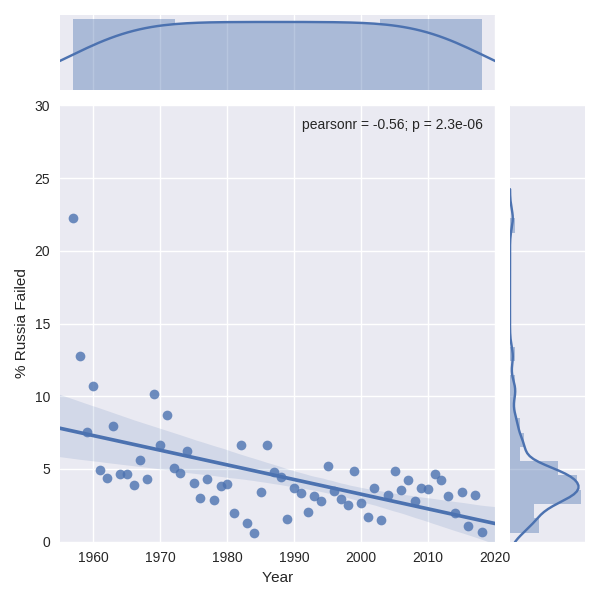

In [18]:
# Figure 9: Russia jointplot with the y axis restricted to 30% value
fig_9 = sns.jointplot(launch_country_status.index, launch_country_status['% Russia Failed'], kind='reg', 
                      xlim=[1955, 2020], ylim=[0, 30]);

### From the given distributions, a different tendency of cases of failed space launches of the United States and Russia is visible. The former have a sharp decrease in failures and a stable retention within 5%, the latter have a wider band of variation and a more gradual decrease in failures.

### It remains only to wish all countries a further tendency to reduce failed launches!